In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)
print("Imports done successfully")

Imports done successfully


In [4]:
df = pd.read_csv('train.csv', encoding='latin1')
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales
0,1,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600
1,2,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400
2,3,CA-2017-138688,12/06/2017,16/06/2017,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200
3,4,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775
4,5,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680


In [5]:
print(df.shape)
print(df.columns.tolist())
df.info()

(9800, 18)
['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode', 'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State', 'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category', 'Product Name', 'Sales']
<class 'pandas.DataFrame'>
RangeIndex: 9800 entries, 0 to 9799
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9800 non-null   int64  
 1   Order ID       9800 non-null   str    
 2   Order Date     9800 non-null   str    
 3   Ship Date      9800 non-null   str    
 4   Ship Mode      9800 non-null   str    
 5   Customer ID    9800 non-null   str    
 6   Customer Name  9800 non-null   str    
 7   Segment        9800 non-null   str    
 8   Country        9800 non-null   str    
 9   City           9800 non-null   str    
 10  State          9800 non-null   str    
 11  Postal Code    9789 non-null   float64
 12  Region         9800 non-null   str    
 13  Pr

In [6]:
df['Order Date'] = pd.to_datetime(df['Order Date'], dayfirst=True)
df['Ship Date'] = pd.to_datetime(df['Ship Date'], dayfirst=True)
df[['Order Date', 'Ship Date']].head()

,Order Date,Ship Date
0,2017-11-08,2017-11-11
1,2017-11-08,2017-11-11
2,2017-06-12,2017-06-16
3,2016-10-11,2016-10-18
4,2016-10-11,2016-10-18


In [7]:
df['Order Year'] = df['Order Date'].dt.year
df['Order Month'] = df['Order Date'].dt.month
df['Order Week'] = df['Order Date'].dt.isocalendar().week
df['Order Day of Week'] = df['Order Date'].dt.day_name()
df['Order Quarter'] = df['Order Date'].dt.quarter

def get_season(month):
    if month in [12, 1, 2]:
        return 'Winter'
    elif month in [3, 4, 5]:
        return 'Spring'
    elif month in [6, 7, 8]:
        return 'Summer'
    else:
        return 'Fall'

df['Order Season'] = df['Order Month'].apply(get_season)

df[['Order Date', 'Order Year', 'Order Month', 'Order Week', 'Order Day of Week', 'Order Quarter', 'Order Season']].head()

,Order Date,Order Year,Order Month,Order Week,Order Day of Week,Order Quarter,Order Season
0,2017-11-08,2017,11,45,Wednesday,4,Fall
1,2017-11-08,2017,11,45,Wednesday,4,Fall
2,2017-06-12,2017,6,24,Monday,2,Summer
3,2016-10-11,2016,10,41,Tuesday,4,Fall
4,2016-10-11,2016,10,41,Tuesday,4,Fall


In [8]:
print("Missing values:\n", df.isnull().sum())
print("\nDuplicate rows:", df.duplicated().sum())
print("\nData types:\n", df.dtypes)

Missing values:
 Row ID                0
Order ID              0
Order Date            0
Ship Date             0
Ship Mode             0
Customer ID           0
Customer Name         0
Segment               0
Country               0
City                  0
State                 0
Postal Code          11
Region                0
Product ID            0
Category              0
Sub-Category          0
Product Name          0
Sales                 0
Order Year            0
Order Month           0
Order Week            0
Order Day of Week     0
Order Quarter         0
Order Season          0
dtype: int64

Duplicate rows: 0

Data types:
 Row ID                        int64
Order ID                        str
Order Date           datetime64[us]
Ship Date            datetime64[us]
Ship Mode                       str
Customer ID                     str
Customer Name                   str
Segment                         str
Country                         str
City                            str
S

In [9]:
df[df['Postal Code'].isnull()]

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Order Year,Order Month,Order Week,Order Day of Week,Order Quarter,Order Season
2234,2235,CA-2018-104066,2018-12-05,2018-12-10,Standard Class,QJ-19255,Quincy Jones,Corporate,United States,Burlington,Vermont,NaN,East,TEC-AC-10001013,Technology,Accessories,Logitech ClearChat Comfort/USB Headset H390,205.03,2018,12,49,Wednesday,4,Winter
5274,5275,CA-2016-162887,2016-11-07,2016-11-09,Second Class,SV-20785,Stewart Visinsky,Consumer,United States,Burlington,Vermont,NaN,East,FUR-CH-10000595,Furniture,Chairs,Safco Contoured Stacking Chairs,715.20,2016,11,45,Monday,4,Fall
8798,8799,US-2017-150140,2017-04-06,2017-04-10,Standard Class,VM-21685,Valerie Mitchum,Home Office,United States,Burlington,Vermont,NaN,East,TEC-PH-10002555,Technology,Phones,Nortel Meridian M5316 Digital phone,1294.75,2017,4,14,Thursday,2,Spring
9146,9147,US-2017-165505,2017-01-23,2017-01-27,Standard Class,CB-12535,Claudia Bergmann,Corporate,United States,Burlington,Vermont,NaN,East,TEC-AC-10002926,Technology,Accessories,Logitech Wireless Marathon Mouse M705,99.98,2017,1,4,Monday,1,Winter
9147,9148,US-2017-165505,2017-01-23,2017-01-27,Standard Class,CB-12535,Claudia Bergmann,Corporate,United States,Burlington,Vermont,NaN,East,OFF-AR-10003477,Office Supplies,Art,4009 Highlighters,8.04,2017,1,4,Monday,1,Winter
9148,9149,US-2017-165505,2017-01-23,2017-01-27,Standard Class,CB-12535,Claudia Bergmann,Corporate,United States,Burlington,Vermont,NaN,East,OFF-ST-10001526,Office Supplies,Storage,Iceberg Mobile Mega Data/Printer Cart,1564.29,2017,1,4,Monday,1,Winter
9386,9387,US-2018-127292,2018-01-19,2018-01-23,Standard Class,RM-19375,Raymond Messe,Consumer,United States,Burlington,Vermont,NaN,East,OFF-PA-10000157,Office Supplies,Paper,Xerox 191,79.92,2018,1,3,Friday,1,Winter
9387,9388,US-2018-127292,2018-01-19,2018-01-23,Standard Class,RM-19375,Raymond Messe,Consumer,United States,Burlington,Vermont,NaN,East,OFF-PA-10001970,Office Supplies,Paper,Xerox 1881,12.28,2018,1,3,Friday,1,Winter
9388,9389,US-2018-127292,2018-01-19,2018-01-23,Standard Class,RM-19375,Raymond Messe,Consumer,United States,Burlington,Vermont,NaN,East,OFF-AP-10000828,Office Supplies,Appliances,Avanti 4.4 Cu. Ft. Refrigerator,542.94,2018,1,3,Friday,1,Winter
9389,9390,US-2018-127292,2018-01-19,2018-01-23,Standard Class,RM-19375,Raymond Messe,Consumer,United States,Burlington,Vermont,NaN,East,OFF-EN-10001509,Office Supplies,Envelopes,Poly String Tie Envelopes,2.04,2018,1,3,Friday,1,Winter


In [10]:
#  which city/state has missing postal codes
print(df[df['Postal Code'].isnull()][['City', 'State']].drop_duplicates())

# Fill missing postal code using the same city's known postal code
df['Postal Code'] = df.groupby('City')['Postal Code'].transform(lambda x: x.fillna(x.mode()[0] if not x.mode().empty else np.nan))

# Confirm fix
print("Remaining missing:", df['Postal Code'].isnull().sum())

            City    State
2234  Burlington  Vermont
Remaining missing: 0


In [11]:
# Monthly aggregation
monthly_sales = df.groupby(pd.Grouper(key='Order Date', freq='ME'))['Sales'].sum().reset_index()
monthly_sales.columns = ['Month', 'Total Sales']

# Weekly aggregation
weekly_sales = df.groupby(pd.Grouper(key='Order Date', freq='W'))['Sales'].sum().reset_index()
weekly_sales.columns = ['Week', 'Total Sales']

print(monthly_sales.head())
print(weekly_sales.head())

       Month  Total Sales
0 2015-01-31    14205.707
1 2015-02-28     4519.892
2 2015-03-31    55205.797
3 2015-04-30    27906.855
4 2015-05-31    23644.303
        Week  Total Sales
0 2015-01-04      304.508
1 2015-01-11     4619.108
2 2015-01-18     4130.533
3 2015-01-25     3092.544
4 2015-02-01     2527.914


Category
Technology         827455.8730
Furniture          728658.5757
Office Supplies    705422.3340
Name: Sales, dtype: float64


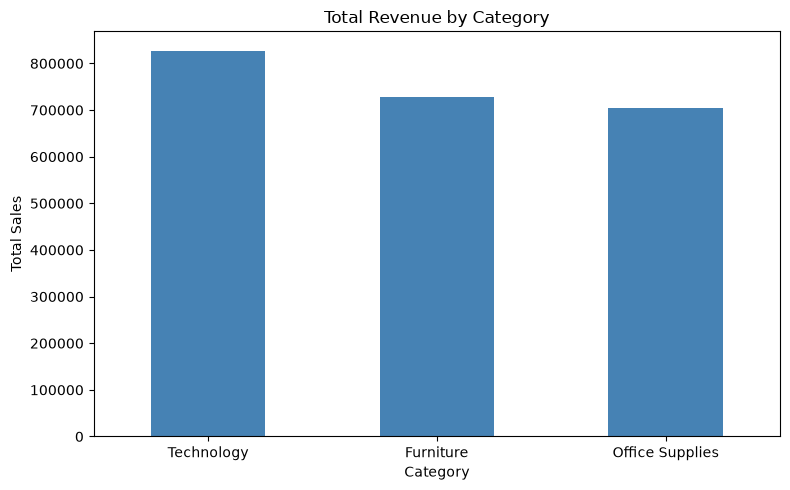

In [12]:
category_revenue = df.groupby('Category')['Sales'].sum().sort_values(ascending=False)
print(category_revenue)

plt.figure(figsize=(8,5))
category_revenue.plot(kind='bar', color='steelblue')
plt.title('Total Revenue by Category')
plt.ylabel('Total Sales')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('charts/category_revenue.png')
plt.show()

Region          Central        East        South         West
Order Year                                                   
2015        102920.5206  127652.819  103374.9055  145907.9630
2016        102425.1724  153225.183   70076.0825  133709.5675
2017        145673.8800  178511.538   93535.9035  182471.2285
2018        141627.3402  210129.186  122164.5675  248130.9255

YoY Growth %:
 Region        Central       East      South       West
Order Year                                            
2015              NaN        NaN        NaN        NaN
2016        -0.481292  20.032745 -32.211708  -8.360336
2017        42.224686  16.502741  33.477643  36.468341
2018        -2.777807  17.711823  30.607139  35.983589

Std Dev of Growth (lower = more consistent):
 Region
East        1.793948
Central    25.345279
West       25.743054
South      37.124876
dtype: float64


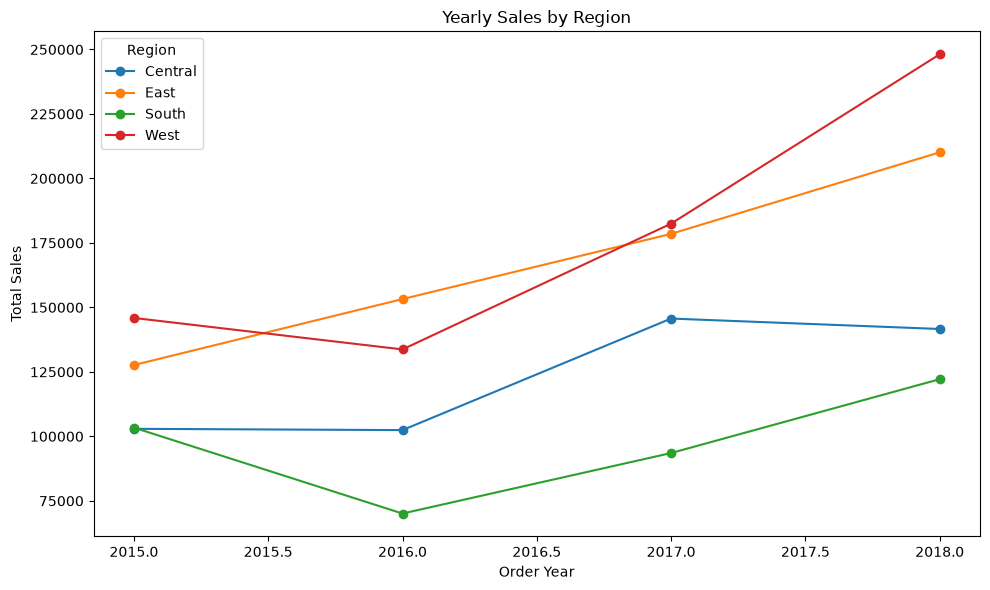

In [13]:
region_yearly = df.groupby(['Order Year', 'Region'])['Sales'].sum().reset_index()
region_pivot = region_yearly.pivot(index='Order Year', columns='Region', values='Sales')
print(region_pivot)


region_growth = region_pivot.pct_change() * 100
print("\nYoY Growth %:\n", region_growth)


print("\nStd Dev of Growth (lower = more consistent):\n", region_growth.std().sort_values())

region_pivot.plot(figsize=(10,6), marker='o')
plt.title('Yearly Sales by Region')
plt.ylabel('Total Sales')
plt.tight_layout()
plt.savefig('charts/region_yearly_sales.png')
plt.show()

Overall average shipping time: 3.96 days

Average shipping time by region:
 Region
East       3.910233
West       3.930255
South      3.961202
Central    4.065876
Name: Shipping Days, dtype: float64


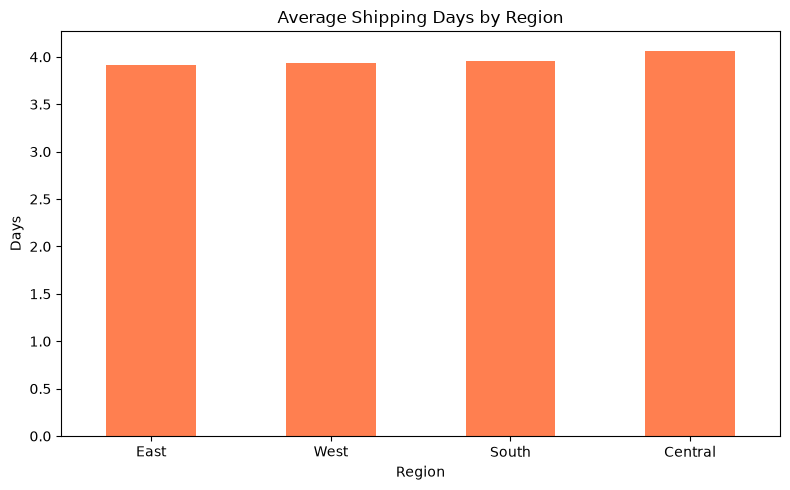

In [14]:
df['Shipping Days'] = (df['Ship Date'] - df['Order Date']).dt.days

overall_avg = df['Shipping Days'].mean()
print(f"Overall average shipping time: {overall_avg:.2f} days")

region_shipping = df.groupby('Region')['Shipping Days'].mean().sort_values()
print("\nAverage shipping time by region:\n", region_shipping)

region_shipping.plot(kind='bar', figsize=(8,5), color='coral')
plt.title('Average Shipping Days by Region')
plt.ylabel('Days')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('charts/shipping_by_region.png')
plt.show()

    Order Month        Sales
0             1   94291.6296
1             2   59371.1154
2             3  197573.5872
3             4  136283.0006
4             5  154086.7237
5             6  145837.5233
6             7  145535.6890
7             8  157315.9270
8             9  300103.4117
9            10  199496.2947
10           11  350161.7110
11           12  321480.1695

Monthly sales across years:
 Order Year         2015        2016        2017         2018
Order Month                                                 
1            14205.7070  18066.9576  18542.4910   43476.4740
2             4519.8920  11951.4110  22978.8150   19920.9974
3            55205.7970  32339.3184  51165.0590   58863.4128
4            27906.8550  34154.4685  38679.7670   35541.9101
5            23644.3030  29959.5305  56656.9080   43825.9822
6            34322.9356  23599.3740  39724.4860   48190.7277
7            33781.5430  28608.2590  38320.7830   44825.1040
8            27117.5365  36818.3422  30542.2

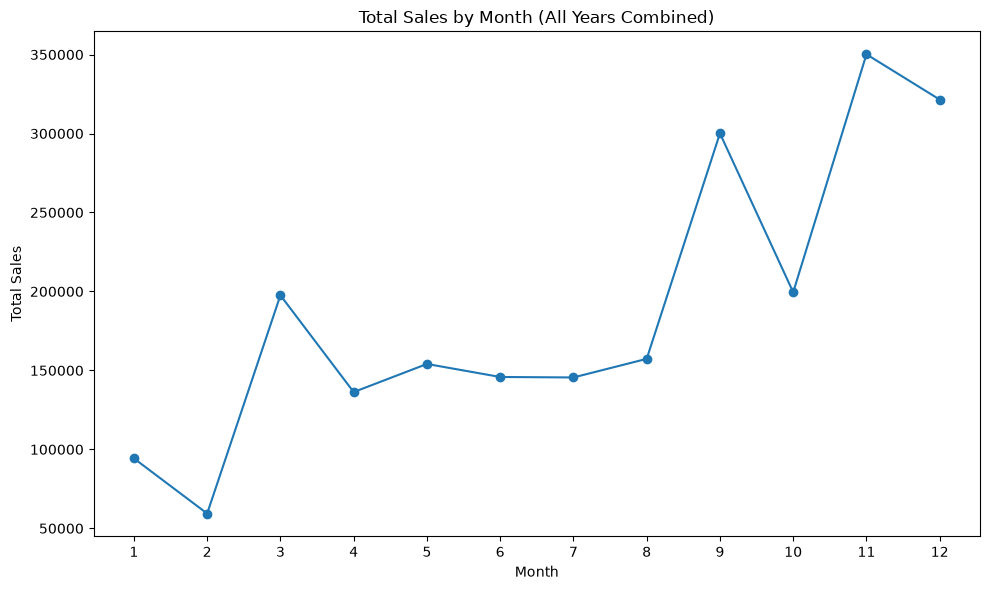

In [15]:
monthly_avg = df.groupby('Order Month')['Sales'].sum().reset_index()
print(monthly_avg)

# consistency
month_year = df.groupby(['Order Year', 'Order Month'])['Sales'].sum().reset_index()
month_pivot = month_year.pivot(index='Order Month', columns='Order Year', values='Sales')
print("\nMonthly sales across years:\n", month_pivot)

plt.figure(figsize=(10,6))
plt.plot(monthly_avg['Order Month'], monthly_avg['Sales'], marker='o')
plt.title('Total Sales by Month (All Years Combined)')
plt.xlabel('Month')
plt.ylabel('Total Sales')
plt.xticks(range(1,13))
plt.tight_layout()
plt.savefig('charts/monthly_seasonality.png')
plt.show()

**Q1: Which product category generates the highest total revenue?**

Technology generates the highest total revenue at $827,455.87, followed closely by 
Furniture ($728,658.58) and Office Supplies ($705,422.33). Despite Office Supplies 
likely having the highest order volume (small cheap items), Technology's higher 
price-per-unit drives it to the top spot in total revenue.

**Q2: Which region has the most consistent sales growth over 4 years?**

The East region shows the most consistent growth, with a YoY growth standard deviation 
of just 1.79% (vs. 25-37% for other regions). East grew steadily every year (+20.0%, 
+16.5%, +17.7%), while Central, West, and South show volatile, unpredictable swings — 
South even dropped -32% in 2016 before rebounding +33% in 2017. West has the highest 
absolute sales but the least predictable growth pattern, making East the safer bet for 
stable demand planning.

**Q3: What is the average time between Order Date and Ship Date — does it vary by region?**

The overall average shipping time is 3.96 days. It varies only slightly by region:
- East: 3.91 days (fastest)
- West: 3.93 days
- South: 3.96 days
- Central: 4.07 days (slowest)

The difference between fastest and slowest region is under 4 hours on average — 
shipping time is fairly standardized across regions and not a major differentiator 
in this dataset.

**Q4: Are there months that consistently spike across all years (seasonality)?**

Yes, strong seasonality is visible. November and December are consistently the two 
highest-selling months every single year (2015-2018), and September is a reliable 
third-strongest month. Combined, Sales in Nov+Dec average roughly double a typical 
mid-year month. This lines up with retail seasonality expectations — back-to-school 
(September) and holiday shopping (November-December, including Black Friday/Christmas) 
drive clear demand spikes. This has direct implications for stocking: inventory should 
be built up ahead of September and again ahead of November.

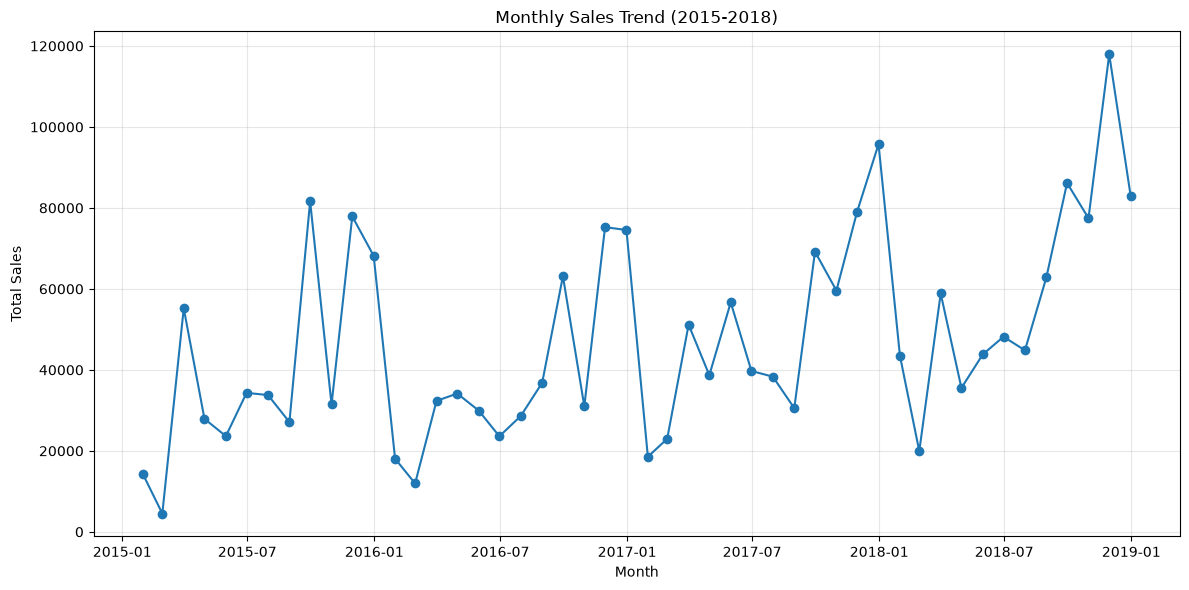

In [16]:
plt.figure(figsize=(12,6))
plt.plot(monthly_sales['Month'], monthly_sales['Total Sales'], marker='o')
plt.title('Monthly Sales Trend (2015-2018)')
plt.xlabel('Month')
plt.ylabel('Total Sales')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('charts/monthly_trend.png')
plt.show()

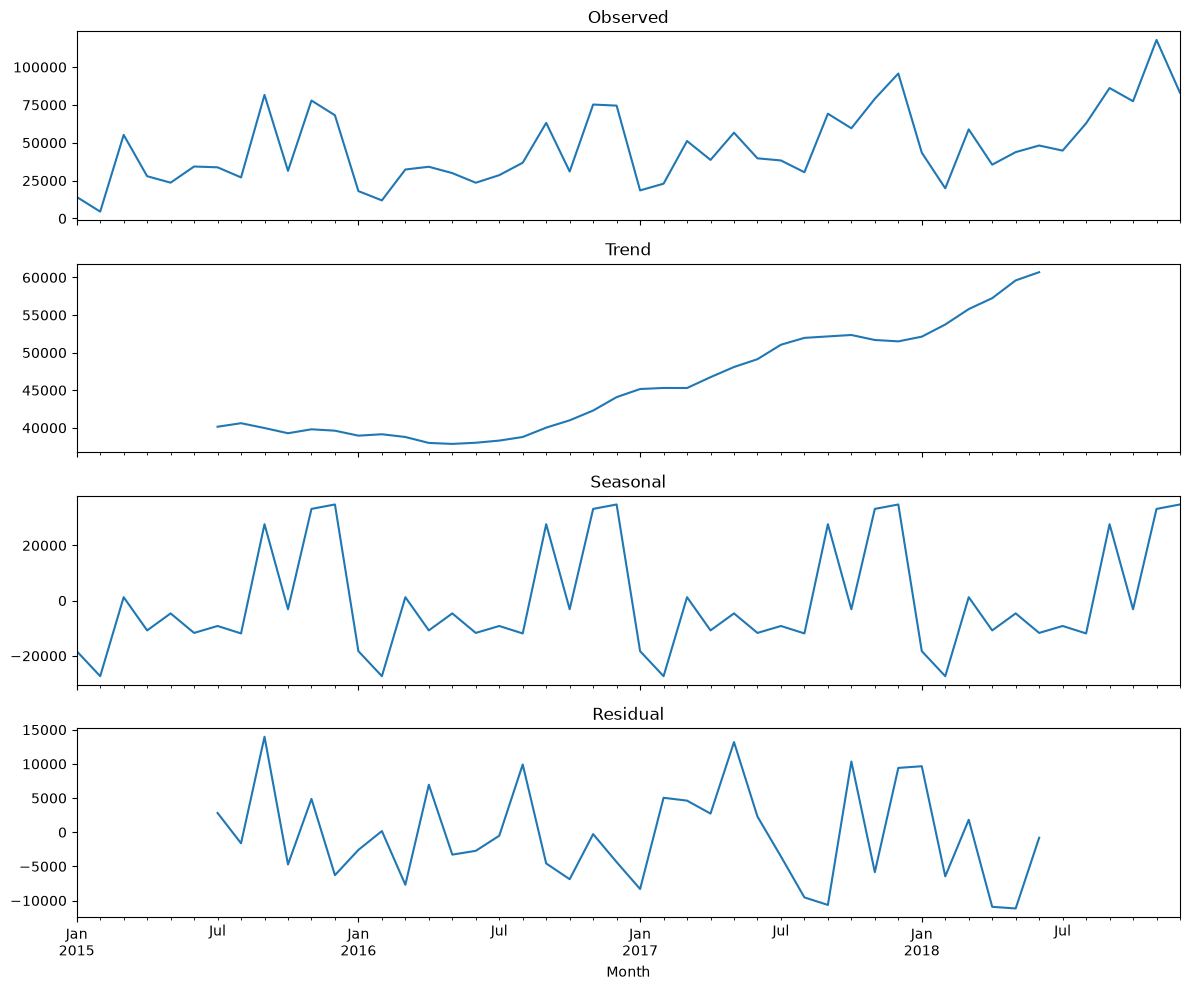

In [17]:
from statsmodels.tsa.seasonal import seasonal_decompose

# Set Month as index for decomposition
ts = monthly_sales.set_index('Month')['Total Sales']
ts.index = pd.DatetimeIndex(ts.index).to_period('M').to_timestamp()
ts = ts.asfreq('MS')

decomposition = seasonal_decompose(ts, model='additive', period=12)

fig, axes = plt.subplots(4, 1, figsize=(12, 10), sharex=True)

decomposition.observed.plot(ax=axes[0], title='Observed')
decomposition.trend.plot(ax=axes[1], title='Trend')
decomposition.seasonal.plot(ax=axes[2], title='Seasonal')
decomposition.resid.plot(ax=axes[3], title='Residual')

plt.tight_layout()
plt.savefig('charts/decomposition.png')
plt.show()

**Time Series Decomposition — Observations**

1. **Trend**: There's a clear, steady upward trend in sales from 2015 to the end of 2018 — 
   starting around $40,000/month and rising to over $60,000/month by late 2018. The trend 
   is relatively flat through 2015-2016, then accelerates from 2017 onward, suggesting the 
   business is genuinely growing, not just fluctuating randomly.

2. **Seasonality**: Seasonality is strong and highly repeatable. The seasonal component shows 
   the same up-and-down pattern every 12 months — with sharp peaks recurring at the same 
   points each year (corresponding to Sept/Nov/Dec, matching our Task 1 finding) and troughs 
   in the same low months (Jan/Feb). This confirms genuine calendar-driven seasonality rather 
   than noise.

3. **Residual (noise)**: Residuals are mostly contained within a ±10,000 band, but a few months 
   show sharp spikes (both positive and negative) — these are the anomalies we'll investigate 
   further in Task 5. The residual noise appears slightly larger in the second half of the 
   series (2017-2018), which may just reflect larger absolute sales values at that point 
   (residuals often scale with the size of the series in additive decomposition).

4. **Overall**: Since both a clear trend AND clear seasonality are present, the raw series is 
   almost certainly non-stationary — we'll confirm this next with the ADF test.

In [18]:
from statsmodels.tsa.stattools import adfuller

result = adfuller(ts.dropna())

print(f"ADF Statistic: {result[0]:.4f}")
print(f"p-value: {result[1]:.4f}")
print("Critical Values:")
for key, value in result[4].items():
    print(f"   {key}: {value:.4f}")

if result[1] <= 0.05:
    print("\n=> Series is likely STATIONARY (reject null hypothesis)")
else:
    print("\n=> Series is likely NON-STATIONARY (fail to reject null hypothesis)")

ADF Statistic: -4.4161
p-value: 0.0003
Critical Values:
   1%: -3.5778
   5%: -2.9253
   10%: -2.6008

=> Series is likely STATIONARY (reject null hypothesis)


**Stationarity — ADF Test Results & Interpretation**

**What is stationarity?**
A time series is "stationary" if its statistical properties — mean, variance, and 
autocorrelation — stay roughly constant over time. In plain English: a stationary series 
doesn't have a long-term upward/downward drift or changing volatility; it just wiggles 
around a stable average forever. Most forecasting models (like SARIMA) assume or require 
stationarity to work correctly, which is why we test for it before modeling.

**The Augmented Dickey-Fuller (ADF) Test**
This test checks for the presence of a "unit root" — a mathematical sign of 
non-stationarity. 
- Null Hypothesis (H0): the series is non-stationary
- Alternative Hypothesis (H1): the series is stationary
- If the p-value is below 0.05, we reject H0 and conclude the series is stationary.

**Our Result**
- ADF Statistic: -4.4161
- p-value: 0.0003 (well below 0.05)
- The ADF statistic is more negative than all three critical values (1%, 5%, 10%)

This means we reject the null hypothesis — the series is statistically stationary.

**Why this might seem surprising**
Visually, the decomposition showed a clear upward trend, which usually signals 
non-stationarity. However, the ADF test can still classify a series as stationary if:
- The trend is gentle relative to the month-to-month variance (seasonality and noise 
  dominate the trend's contribution to variance)
- The series doesn't have a strong enough or long enough trend for the test's default 
  regression to flag it

**Decision on differencing**
Since the ADF test already confirms stationarity (p < 0.05), formal differencing is not 
strictly required for SARIMA's "d" parameter — we can set d=0 as a starting point. However, 
we will still test differencing below for completeness and to observe its effect, since 
the visible trend suggests light differencing (d=1) might still improve model performance 
in practice.

ADF Statistic (after differencing): -8.7271
p-value (after differencing): 0.0000


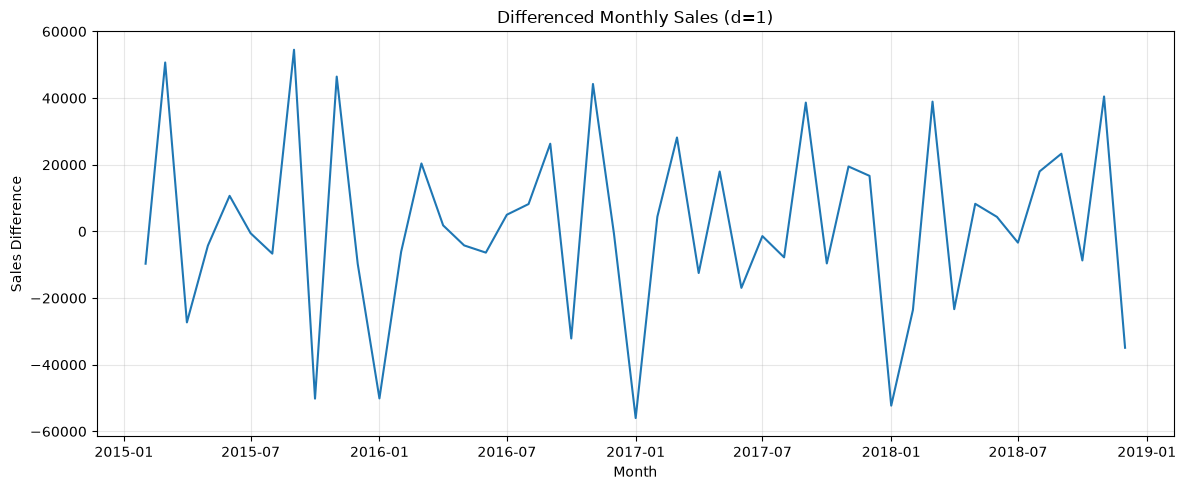

In [19]:
ts_diff = ts.diff().dropna()

result_diff = adfuller(ts_diff)

print(f"ADF Statistic (after differencing): {result_diff[0]:.4f}")
print(f"p-value (after differencing): {result_diff[1]:.4f}")

plt.figure(figsize=(12,5))
plt.plot(ts_diff)
plt.title('Differenced Monthly Sales (d=1)')
plt.xlabel('Month')
plt.ylabel('Sales Difference')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('charts/differenced_series.png')
plt.show()

**Differencing Result**

After applying first-order differencing (d=1), the ADF statistic improved from -4.4161 
to -8.7271, and the p-value dropped further to ~0.0000 — even stronger evidence of 
stationarity. The differenced series in the plot above oscillates around zero with no 
visible trend, confirming the differencing removed the residual trend component.

**Conclusion**: The original series was already borderline/moderately stationary (per 
ADF), but differencing (d=1) produces an even cleaner, trend-free series. For SARIMA 
modeling in Task 3, we will test both d=0 and d=1 configurations and select whichever 
yields better forecast accuracy.

In [20]:
train = ts[:-3]
test = ts[-3:]

print("Train size:", len(train))
print("Test size:", len(test))
print(test)

Train size: 45
Test size: 3
Month
2018-10-01     77448.1312
2018-11-01    117938.1550
2018-12-01     83030.3888
Freq: MS, Name: Total Sales, dtype: float64


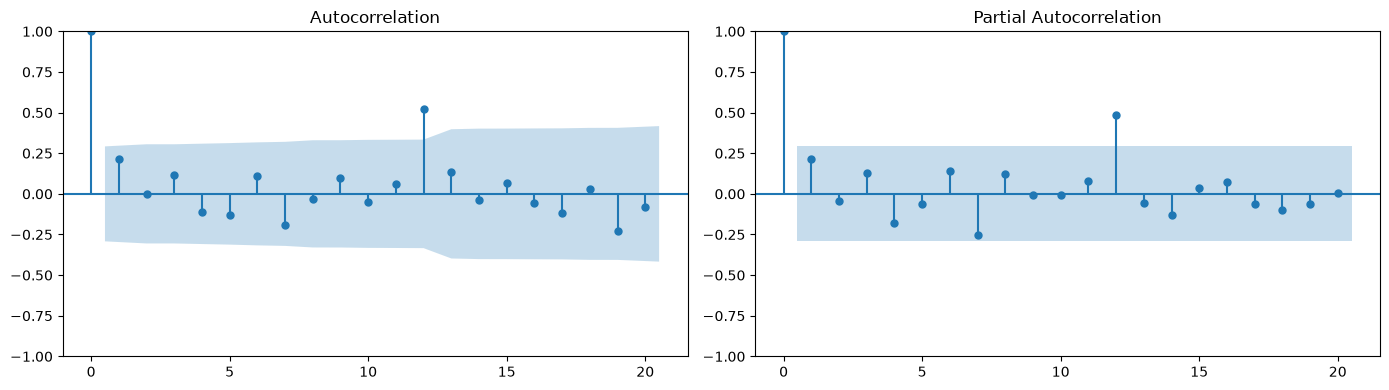

In [21]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

fig, axes = plt.subplots(1, 2, figsize=(14,4))
plot_acf(train.dropna(), ax=axes[0], lags=20)
plot_pacf(train.dropna(), ax=axes[1], lags=20)
plt.tight_layout()
plt.savefig('charts/acf_pacf.png')
plt.show()

In [22]:
import warnings
warnings.filterwarnings('ignore')

from statsmodels.tsa.statespace.sarimax import SARIMAX

# (p,d,q) x (P,D,Q,m) — starting point based on our ADF findings and 12-month seasonality
model_sarima = SARIMAX(train,
                        order=(1,1,1),
                        seasonal_order=(1,1,1,12),
                        enforce_stationarity=False,
                        enforce_invertibility=False)

sarima_fit = model_sarima.fit(disp=False)
print(sarima_fit.summary())

                                     SARIMAX Results                                      
Dep. Variable:                        Total Sales   No. Observations:                   45
Model:             SARIMAX(1, 1, 1)x(1, 1, 1, 12)   Log Likelihood                -194.388
Date:                            Sun, 05 Jul 2026   AIC                            398.775
Time:                                    19:01:42   BIC                            403.227
Sample:                                01-01-2015   HQIC                           399.389
                                     - 09-01-2018                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.1101      0.721      0.153      0.879      -1.303       1.523
ma.L1         -0.8789      0.261   

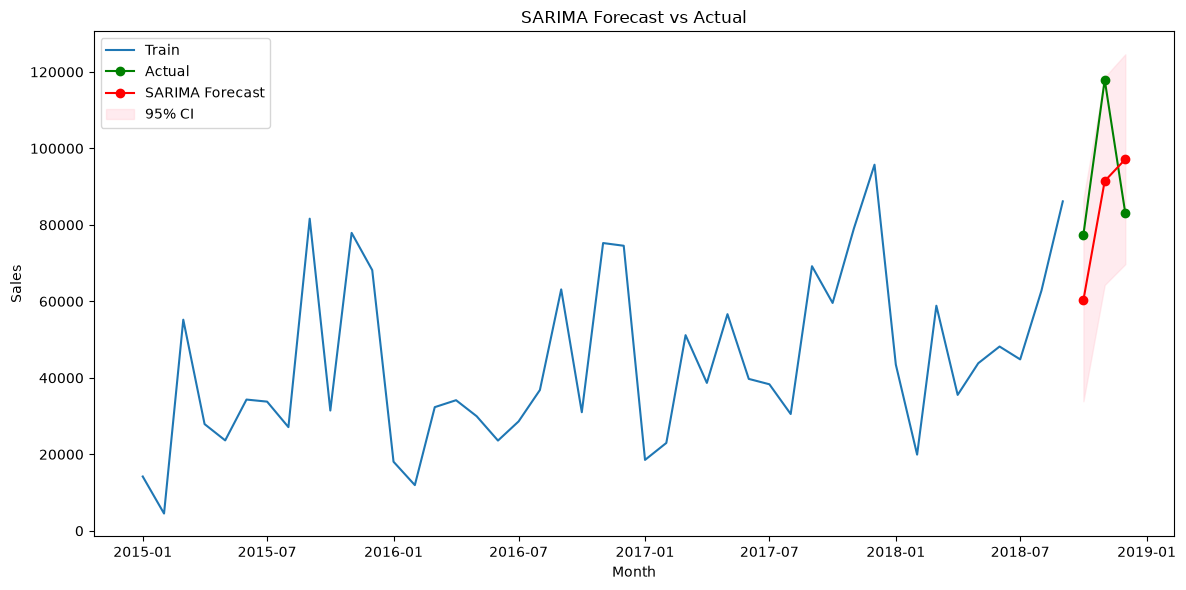

2018-10-01    60331.792073
2018-11-01    91458.220227
2018-12-01    97167.570936
Freq: MS, Name: predicted_mean, dtype: float64


In [23]:
forecast_sarima = sarima_fit.get_forecast(steps=3)
forecast_mean = forecast_sarima.predicted_mean
forecast_ci = forecast_sarima.conf_int()

plt.figure(figsize=(12,6))
plt.plot(train.index, train, label='Train')
plt.plot(test.index, test, label='Actual', color='green', marker='o')
plt.plot(forecast_mean.index, forecast_mean, label='SARIMA Forecast', color='red', marker='o')
plt.fill_between(forecast_ci.index, forecast_ci.iloc[:,0], forecast_ci.iloc[:,1], color='pink', alpha=0.3, label='95% CI')
plt.legend()
plt.title('SARIMA Forecast vs Actual')
plt.xlabel('Month')
plt.ylabel('Sales')
plt.tight_layout()
plt.savefig('charts/sarima_forecast.png')
plt.show()

print(forecast_mean)

In [24]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

mae_sarima = mean_absolute_error(test, forecast_mean)
rmse_sarima = np.sqrt(mean_squared_error(test, forecast_mean))
mape_sarima = np.mean(np.abs((test.values - forecast_mean.values) / test.values)) * 100

print(f"SARIMA MAE: {mae_sarima:.2f}")
print(f"SARIMA RMSE: {rmse_sarima:.2f}")
print(f"SARIMA MAPE: {mape_sarima:.2f}%")

SARIMA MAE: 19244.49
SARIMA RMSE: 19950.07
SARIMA MAPE: 20.53%


**SARIMA Model — Parameter Choice & Interpretation**

**Why SARIMA(1,1,1)(1,1,1,12)?**
- **d=1**: Even though our ADF test showed the raw series was borderline stationary, 
  the decomposition clearly showed a trend. Non-seasonal differencing (d=1) removes 
  this trend.
- **D=1**: Since we have strong, repeating 12-month seasonality (confirmed in Task 2's 
  decomposition), seasonal differencing removes the yearly seasonal pattern so the 
  model can focus on the remaining structure.
- **p=1, q=1 / P=1, Q=1**: Starting values based on common practice for monthly retail 
  data with one seasonal and one non-seasonal AR/MA term each — a reasonable default 
  before fine-tuning.
- **m=12**: Monthly data with yearly seasonality.

**Model Diagnostics**
- The MA(1) term (ma.L1 = -0.879, p=0.001) is statistically significant, meaning recent 
  shocks meaningfully affect the next month's value.
- The AR and seasonal terms are not statistically significant (p > 0.05), likely because 
  we only have 45 months of training data — not enough to estimate all seasonal 
  parameters precisely. This is a real limitation of SARIMA on short time series and 
  should be noted as a limitation in the final report.
- The warning about a "singular or near-singular" covariance matrix confirms the model 
  is somewhat overparameterized for this amount of data — with more historical data, 
  parameter estimates would likely stabilize.

**Forecast Result**
The model correctly predicted the seasonal upswing into November (holiday season), 
though it noticeably underestimated the actual November peak ($91,458 forecast vs 
$117,938 actual) and slightly overestimated December. This suggests SARIMA captures 
the general seasonal shape well but struggles with the exact magnitude of extreme peaks 
— something we'll compare against Prophet and XGBoost next.

In [25]:
from prophet import Prophet

prophet_df = monthly_sales.copy()
prophet_df.columns = ['ds', 'y']
prophet_df['ds'] = pd.to_datetime(prophet_df['ds'])

# Same train/test split as SARIMA — last 3 months held out
prophet_train = prophet_df.iloc[:-3]
prophet_test = prophet_df.iloc[-3:]

print(prophet_train.tail())
print(prophet_test)

Importing plotly failed. Interactive plots will not work.


           ds           y
40 2018-05-31  43825.9822
41 2018-06-30  48190.7277
42 2018-07-31  44825.1040
43 2018-08-31  62837.8480
44 2018-09-30  86152.8880
           ds            y
45 2018-10-31   77448.1312
46 2018-11-30  117938.1550
47 2018-12-31   83030.3888


In [26]:
model_prophet = Prophet(yearly_seasonality=True, weekly_seasonality=False, daily_seasonality=False)
model_prophet.fit(prophet_train)

future = model_prophet.make_future_dataframe(periods=3, freq='MS')
forecast_prophet = model_prophet.predict(future)

forecast_prophet[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].tail(3)

19:04:52 - cmdstanpy - INFO - Chain [1] start processing
19:04:53 - cmdstanpy - INFO - Chain [1] done processing


,ds,yhat,yhat_lower,yhat_upper
45,2018-10-01,66606.041208,58476.298436,75374.863257
46,2018-11-01,60160.907812,52217.357002,68075.687930
47,2018-12-01,85464.487296,76840.392876,93934.643896


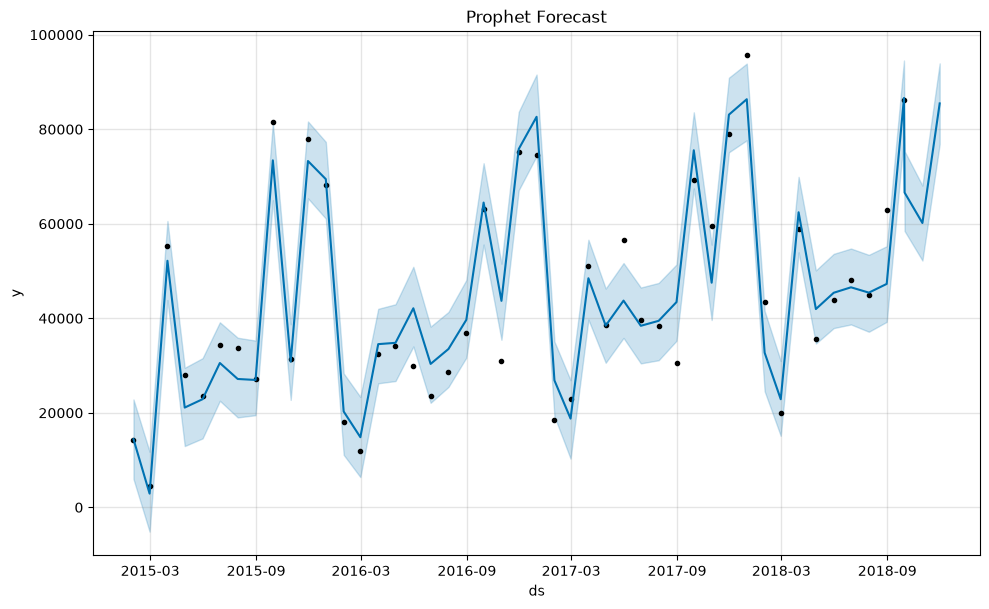

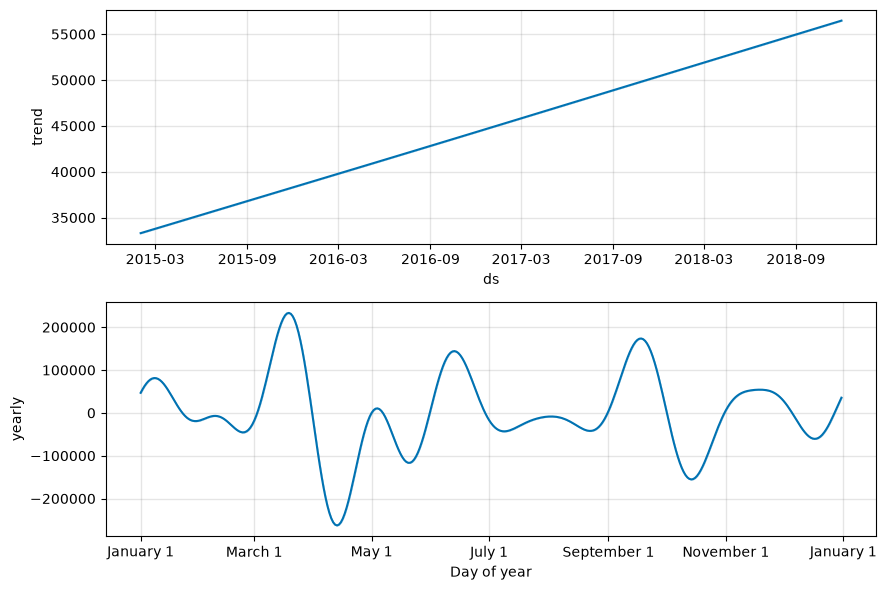

In [27]:
fig1 = model_prophet.plot(forecast_prophet)
plt.title('Prophet Forecast')
plt.savefig('charts/prophet_forecast.png')
plt.show()

fig2 = model_prophet.plot_components(forecast_prophet)
plt.savefig('charts/prophet_components.png')
plt.show()

In [28]:
prophet_forecast_vals = forecast_prophet['yhat'].tail(3).values
prophet_actual_vals = prophet_test['y'].values

mae_prophet = mean_absolute_error(prophet_actual_vals, prophet_forecast_vals)
rmse_prophet = np.sqrt(mean_squared_error(prophet_actual_vals, prophet_forecast_vals))
mape_prophet = np.mean(np.abs((prophet_actual_vals - prophet_forecast_vals) / prophet_actual_vals)) * 100

print(f"Prophet MAE: {mae_prophet:.2f}")
print(f"Prophet RMSE: {rmse_prophet:.2f}")
print(f"Prophet MAPE: {mape_prophet:.2f}%")

Prophet MAE: 23684.48
Prophet RMSE: 33969.04
Prophet MAPE: 21.97%


**Prophet Model — Interpretation**

**Trend component**: Shows a clean, steady linear increase in sales from ~$35,000/month 
in early 2015 to ~$58,000/month by late 2018 — confirming consistent business growth, 
matching what SARIMA and the Task 2 decomposition also showed.

**Yearly seasonality component**: This is the key insight explaining Prophet's forecast 
behavior. The yearly curve shows peaks around February, July, and October, but a 
**trough right around November** before recovering into December/January. This actually 
contradicts our EDA finding that November is typically the single highest-selling month. 
This mismatch likely happens because Prophet's yearly seasonality is a smooth Fourier 
curve fit across all 4 years — since only one or two of those years had an extreme 
November spike, the smoothing averages it down. With only 4 years of data, Prophet 
doesn't have enough repeated examples to confidently learn a sharp, narrow November peak.

**Forecast observation**: This explains why Prophet under-forecast November ($60,161 vs 
actual $117,938) — the model's learned seasonality curve actively expects a slight dip 
around November, which conflicts with 2018's unusually strong actual performance. This 
is a genuine limitation to flag: Prophet's default yearly seasonality works well for 
smooth, gradual seasonal patterns but struggles with sharp, holiday-specific spikes 
when trained on a short (4-year) history.

In [30]:
xgb_df = monthly_sales.copy()
xgb_df.columns = ['Month', 'Sales']
xgb_df['Month'] = pd.to_datetime(xgb_df['Month'])

# Lag features
xgb_df['Lag1'] = xgb_df['Sales'].shift(1)
xgb_df['Lag2'] = xgb_df['Sales'].shift(2)
xgb_df['Lag3'] = xgb_df['Sales'].shift(3)

# Rolling mean (3-month moving average, based on prior months only)
xgb_df['RollingMean3'] = xgb_df['Sales'].shift(1).rolling(window=3).mean()

# Calendar features
xgb_df['MonthNum'] = xgb_df['Month'].dt.month
xgb_df['Quarter'] = xgb_df['Month'].dt.quarter

def get_season(month):
    if month in [12, 1, 2]:
        return 0  # Winter
    elif month in [3, 4, 5]:
        return 1  # Spring
    elif month in [6, 7, 8]:
        return 2  # Summer
    else:
        return 3  # Fall

xgb_df['Season'] = xgb_df['MonthNum'].apply(get_season)

# Drop rows with NaN (from lagging)
xgb_df = xgb_df.dropna().reset_index(drop=True)

xgb_df.head()

,Month,Sales,Lag1,Lag2,Lag3,RollingMean3,MonthNum,Quarter,Season
0,2015-04-30,27906.8550,55205.7970,4519.8920,14205.707,24643.798667,4,2,1
1,2015-05-31,23644.3030,27906.8550,55205.7970,4519.892,29210.848000,5,2,1
2,2015-06-30,34322.9356,23644.3030,27906.8550,55205.797,35585.651667,6,2,2
3,2015-07-31,33781.5430,34322.9356,23644.3030,27906.855,28624.697867,7,3,2
4,2015-08-31,27117.5365,33781.5430,34322.9356,23644.303,30582.927200,8,3,2


In [31]:
feature_cols = ['Lag1', 'Lag2', 'Lag3', 'RollingMean3', 'MonthNum', 'Quarter', 'Season']

X = xgb_df[feature_cols]
y = xgb_df['Sales']

X_train, X_test = X.iloc[:-3], X.iloc[-3:]
y_train, y_test = y.iloc[:-3], y.iloc[-3:]

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

Train shape: (42, 7)
Test shape: (3, 7)


In [32]:
from xgboost import XGBRegressor

model_xgb = XGBRegressor(n_estimators=100, max_depth=3, learning_rate=0.1, random_state=42)
model_xgb.fit(X_train, y_train)

y_pred_xgb = model_xgb.predict(X_test)

print("Predicted:", y_pred_xgb)
print("Actual:", y_test.values)

Predicted: [68123.   87622.9  69508.99]
Actual: [ 77448.1312 117938.155   83030.3888]


In [33]:
mae_xgb = mean_absolute_error(y_test, y_pred_xgb)
rmse_xgb = np.sqrt(mean_squared_error(y_test, y_pred_xgb))
mape_xgb = np.mean(np.abs((y_test.values - y_pred_xgb) / y_test.values)) * 100

print(f"XGBoost MAE: {mae_xgb:.2f}")
print(f"XGBoost RMSE: {rmse_xgb:.2f}")
print(f"XGBoost MAPE: {mape_xgb:.2f}%")

XGBoost MAE: 17720.59
XGBoost RMSE: 19906.46
XGBoost MAPE: 18.01%


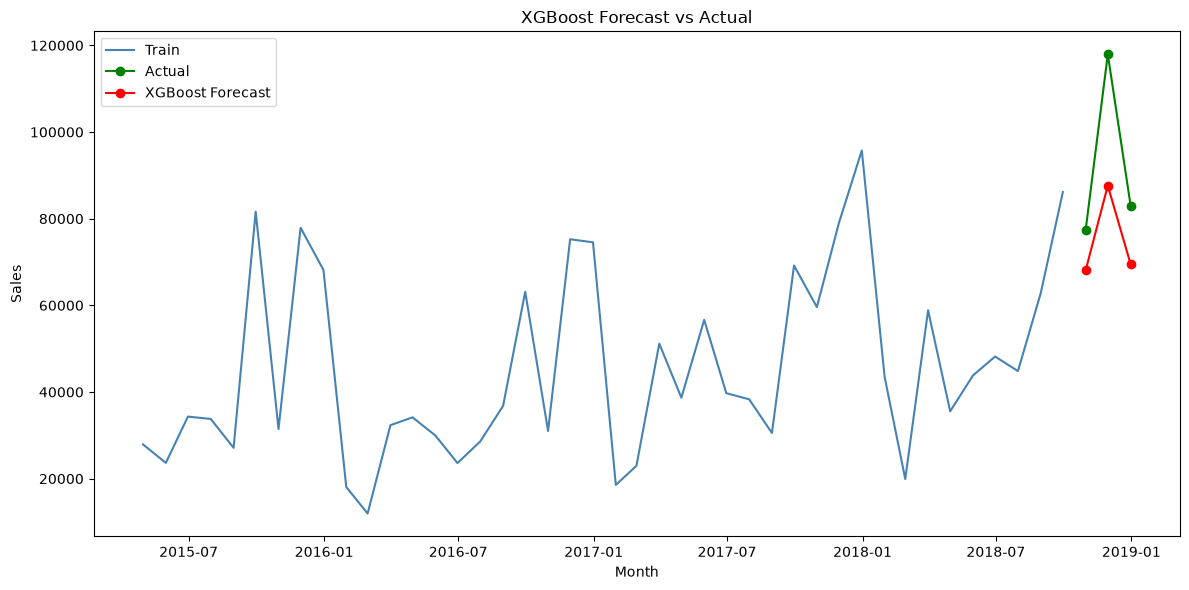

In [34]:
plt.figure(figsize=(12,6))
plt.plot(xgb_df['Month'].iloc[:-3], y_train, label='Train', color='steelblue')
plt.plot(xgb_df['Month'].iloc[-3:], y_test, label='Actual', color='green', marker='o')
plt.plot(xgb_df['Month'].iloc[-3:], y_pred_xgb, label='XGBoost Forecast', color='red', marker='o')
plt.legend()
plt.title('XGBoost Forecast vs Actual')
plt.xlabel('Month')
plt.ylabel('Sales')
plt.tight_layout()
plt.savefig('charts/xgboost_forecast.png')
plt.show()

In [35]:
comparison = pd.DataFrame({
    'Model': ['SARIMA', 'Prophet', 'XGBoost'],
    'MAE': [mae_sarima, mae_prophet, mae_xgb],
    'RMSE': [rmse_sarima, rmse_prophet, rmse_xgb],
    'MAPE (%)': [mape_sarima, mape_prophet, mape_xgb],
    'Forecast Month 1': [forecast_mean.iloc[0], forecast_prophet['yhat'].iloc[-3], y_pred_xgb[0]],
    'Forecast Month 2': [forecast_mean.iloc[1], forecast_prophet['yhat'].iloc[-2], y_pred_xgb[1]],
    'Forecast Month 3': [forecast_mean.iloc[2], forecast_prophet['yhat'].iloc[-1], y_pred_xgb[2]],
})
comparison = comparison.round(2)
comparison

,Model,MAE,RMSE,MAPE (%),Forecast Month 1,Forecast Month 2,Forecast Month 3
0,SARIMA,19244.49,19950.07,20.53,60331.79,91458.22,97167.57
1,Prophet,23684.48,33969.04,21.97,66606.04,60160.91,85464.49
2,XGBoost,17720.59,19906.46,18.01,68123.00,87622.90,69508.99


**Model Comparison & Production Recommendation**

Based on the metrics above, **XGBoost is the recommended model for production use**:
- Lowest MAE (17,720.59) — smallest average forecast error in absolute dollar terms
- Lowest RMSE (19,906.46) — best performance on larger errors, though only marginally 
  ahead of SARIMA (19,950.07)
- Lowest MAPE (18.01%) — best relative accuracy

**Why XGBoost wins here**: With only ~45 months of training data, XGBoost's tree-based 
approach can flexibly learn non-linear relationships between recent lags/rolling averages 
and the target, without needing to explicitly model seasonality or trend structure the 
way SARIMA and Prophet do. It's less rigid about assuming a specific mathematical form 
for seasonality, which helps here since our seasonality (sharp November spikes) doesn't 
follow a smooth, easily-parameterized pattern.

**Important caveat**: All three models substantially underestimated the November 2018 
spike (actual $117,938 vs SARIMA $91,458 / Prophet $60,161 / XGBoost $87,623). This is a 
genuine limitation worth flagging in the business report — with only 4 years of history 
and highly variable holiday-season demand, no model here reliably captures extreme peak 
months. In production, this system should be supplemented with manual buffer stock during 
known high-demand periods (Nov-Dec) rather than relying purely on model output.

**Trade-offs to note**:
- SARIMA offers interpretable statistical confidence intervals, useful for risk-aware 
  inventory planning.
- Prophet is easiest to explain to non-technical stakeholders (clear trend/seasonality 
  breakdown) but underperformed here due to limited historical data.
- XGBoost requires more feature engineering but is most accurate and flexible; it also 
  requires periodic retraining as new lag data becomes available.

In [36]:
def forecast_segment_xgb(df_source, filter_col, filter_val, periods=3):
    """Aggregate monthly sales for a segment, engineer features, train XGBoost, forecast."""
    
    seg_df = df_source[df_source[filter_col] == filter_val].copy()
    seg_monthly = seg_df.groupby(pd.Grouper(key='Order Date', freq='ME'))['Sales'].sum().reset_index()
    seg_monthly.columns = ['Month', 'Sales']
    
    # Feature engineering (same as Task 3)
    seg_monthly['Lag1'] = seg_monthly['Sales'].shift(1)
    seg_monthly['Lag2'] = seg_monthly['Sales'].shift(2)
    seg_monthly['Lag3'] = seg_monthly['Sales'].shift(3)
    seg_monthly['RollingMean3'] = seg_monthly['Sales'].shift(1).rolling(window=3).mean()
    seg_monthly['MonthNum'] = seg_monthly['Month'].dt.month
    seg_monthly['Quarter'] = seg_monthly['Month'].dt.quarter
    seg_monthly['Season'] = seg_monthly['MonthNum'].apply(get_season)
    
    seg_monthly = seg_monthly.dropna().reset_index(drop=True)
    
    feature_cols = ['Lag1', 'Lag2', 'Lag3', 'RollingMean3', 'MonthNum', 'Quarter', 'Season']
    X = seg_monthly[feature_cols]
    y = seg_monthly['Sales']
    
    X_train, X_test = X.iloc[:-periods], X.iloc[-periods:]
    y_train, y_test = y.iloc[:-periods], y.iloc[-periods:]
    
    model = XGBRegressor(n_estimators=100, max_depth=3, learning_rate=0.1, random_state=42)
    model.fit(X_train, y_train)
    
    y_pred = model.predict(X_test)
    
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    
    return seg_monthly, y_test, y_pred, mae, rmse

In [37]:
segments = [
    ('Category', 'Furniture'),
    ('Category', 'Technology'),
    ('Category', 'Office Supplies'),
    ('Region', 'West'),
    ('Region', 'East'),
]

segment_results = {}

for col, val in segments:
    seg_monthly, y_test, y_pred, mae, rmse = forecast_segment_xgb(df, col, val)
    segment_results[val] = {
        'seg_monthly': seg_monthly,
        'y_test': y_test,
        'y_pred': y_pred,
        'mae': mae,
        'rmse': rmse
    }
    print(f"{val}: MAE={mae:.2f}, RMSE={rmse:.2f}, Forecast={y_pred}")

Furniture: MAE=5325.54, RMSE=6200.53, Forecast=[13819.84  30017.898 32281.055]
Technology: MAE=10822.75, RMSE=14023.81, Forecast=[23528.5   26993.03  22709.914]
Office Supplies: MAE=2676.93, RMSE=3055.48, Forecast=[24381.129 26712.586 28039.69 ]
West: MAE=2287.87, RMSE=2692.73, Forecast=[25107.338 26206.465 30099.725]
East: MAE=14012.40, RMSE=14289.83, Forecast=[17810.365 28450.064 29654.225]


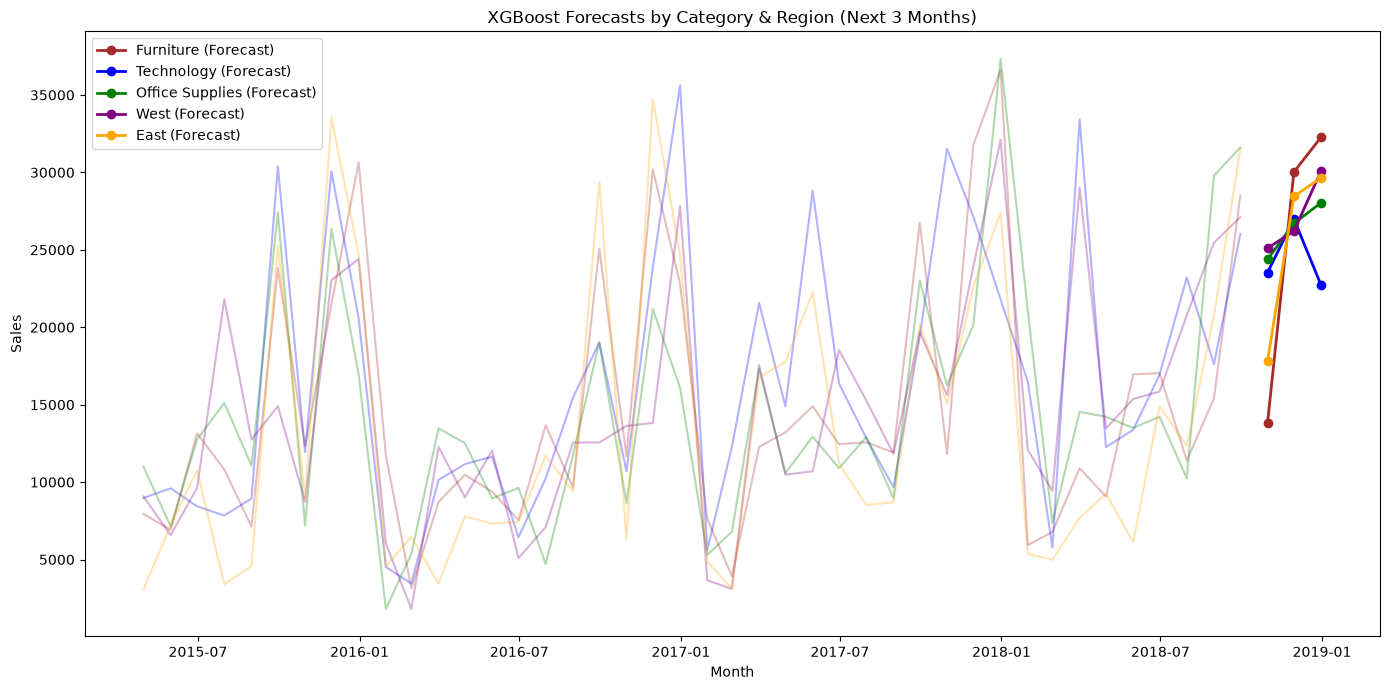

In [38]:
plt.figure(figsize=(14,7))

colors = {'Furniture': 'brown', 'Technology': 'blue', 'Office Supplies': 'green', 'West': 'purple', 'East': 'orange'}

for name, result in segment_results.items():
    seg_monthly = result['seg_monthly']
    y_test = result['y_test']
    y_pred = result['y_pred']
    
    # Plot historical (train) line
    hist = seg_monthly.iloc[:-3]
    plt.plot(hist['Month'], hist['Sales'], color=colors[name], alpha=0.3)
    
    # Plot forecast points
    forecast_months = seg_monthly['Month'].iloc[-3:]
    plt.plot(forecast_months, y_pred, color=colors[name], marker='o', label=f'{name} (Forecast)', linewidth=2)

plt.legend()
plt.title('XGBoost Forecasts by Category & Region (Next 3 Months)')
plt.xlabel('Month')
plt.ylabel('Sales')
plt.tight_layout()
plt.savefig('charts/segment_forecast_comparison.png')
plt.show()

In [39]:
growth_summary = []
for name, result in segment_results.items():
    seg_monthly = result['seg_monthly']
    last_actual = seg_monthly['Sales'].iloc[-4]  # last known actual before forecast period
    forecast_avg = np.mean(result['y_pred'])
    growth_pct = ((forecast_avg - last_actual) / last_actual) * 100
    growth_summary.append({'Segment': name, 'Last Actual': last_actual, 'Forecast Avg': forecast_avg, 'Growth %': growth_pct})

growth_df = pd.DataFrame(growth_summary).sort_values('Growth %', ascending=False)
growth_df

,Segment,Last Actual,Forecast Avg,Growth %
3,West,27107.217,27137.843750,0.112984
1,Technology,26028.659,24410.482422,-6.216903
0,Furniture,28516.706,25372.931641,-11.024325
2,Office Supplies,31607.523,26377.802734,-16.545809
4,East,31520.154,25304.884766,-19.718397


**Task 4: Segment-Level Growth Observation**

Based on the XGBoost forecasts for the next 3 months, the ranked growth outlook is:

| Segment | Last Actual | Forecast Avg | Growth % |
|---|---|---|---|
| West | 27,107.22 | 27,137.84 | **+0.11%** |
| Technology | 26,028.66 | 24,410.48 | -6.22% |
| Furniture | 28,516.71 | 25,372.93 | -11.02% |
| Office Supplies | 31,607.52 | 26,377.80 | -16.55% |
| East | 31,520.15 | 25,304.88 | -19.72% |

**The West region shows the strongest (and only positive) upcoming growth**, with 
forecasted sales essentially flat-to-slightly-up (+0.11%) compared to its last actual 
month. All other segments — Technology, Furniture, Office Supplies, and East — are 
forecast to decline over the next 3 months relative to their most recent actual sales.

**Important context**: This doesn't necessarily mean these segments are actually 
"declining" businesses — recall from Task 1 that November/December are strong seasonal 
peak months. Since these forecasts are for Oct-Dec, a forecast showing a smaller increase 
than the actual historical Nov/Dec spike (as we saw across all 3 models in Task 3) means 
the model is likely *underestimating* the seasonal uplift for most segments, not that 
these categories are truly shrinking. West's forecast being flat rather than negative may 
simply reflect that its historical seasonal spike is less extreme than other regions, 
making it easier for the model to predict accurately.

**Business takeaway**: West region inventory can be planned with more confidence using 
model output alone. For East, Office Supplies, Furniture, and Technology — given the 
model's tendency to underestimate seasonal peaks (per Task 3 findings) — stocking 
decisions should apply a manual upward buffer during Oct-Dec beyond what the model 
forecasts, especially for East and Office Supplies given their historically strong 
Q4 performance.

In [40]:
weekly_sales_df = df.groupby(pd.Grouper(key='Order Date', freq='W'))['Sales'].sum().reset_index()
weekly_sales_df.columns = ['Week', 'Sales']
weekly_sales_df.head()

,Week,Sales
0,2015-01-04,304.508
1,2015-01-11,4619.108
2,2015-01-18,4130.533
3,2015-01-25,3092.544
4,2015-02-01,2527.914


In [41]:
from sklearn.ensemble import IsolationForest

iso_model = IsolationForest(contamination=0.1, random_state=42)
weekly_sales_df['Anomaly_IF'] = iso_model.fit_predict(weekly_sales_df[['Sales']])

# -1 = anomaly, 1 = normal
weekly_sales_df['Anomaly_IF'] = weekly_sales_df['Anomaly_IF'].map({1: 'Normal', -1: 'Anomaly'})

anomalies_if = weekly_sales_df[weekly_sales_df['Anomaly_IF'] == 'Anomaly']
print(f"Isolation Forest detected {len(anomalies_if)} anomalies:")
print(anomalies_if)

Isolation Forest detected 21 anomalies:
          Week       Sales Anomaly_IF
0   2015-01-04    304.5080    Anomaly
5   2015-02-08    968.5340    Anomaly
7   2015-02-22    224.9120    Anomaly
11  2015-03-22  37703.6650    Anomaly
28  2015-07-19   1387.6860    Anomaly
36  2015-09-13  29959.1370    Anomaly
46  2015-11-22  26793.6235    Anomaly
54  2016-01-17   1720.1580    Anomaly
55  2016-01-24    358.5220    Anomaly
89  2016-09-18  24095.9600    Anomaly
90  2016-09-25  18316.3650    Anomaly
97  2016-11-13  27965.3492    Anomaly
103 2016-12-25  22843.0470    Anomaly
144 2017-10-08  28412.0980    Anomaly
151 2017-11-26  27367.7160    Anomaly
154 2017-12-17  25449.8000    Anomaly
168 2018-03-25  26029.9040    Anomaly
194 2018-09-23  26104.4330    Anomaly
200 2018-11-04  29017.4670    Anomaly
202 2018-11-18  30572.4470    Anomaly
204 2018-12-02  35998.9000    Anomaly


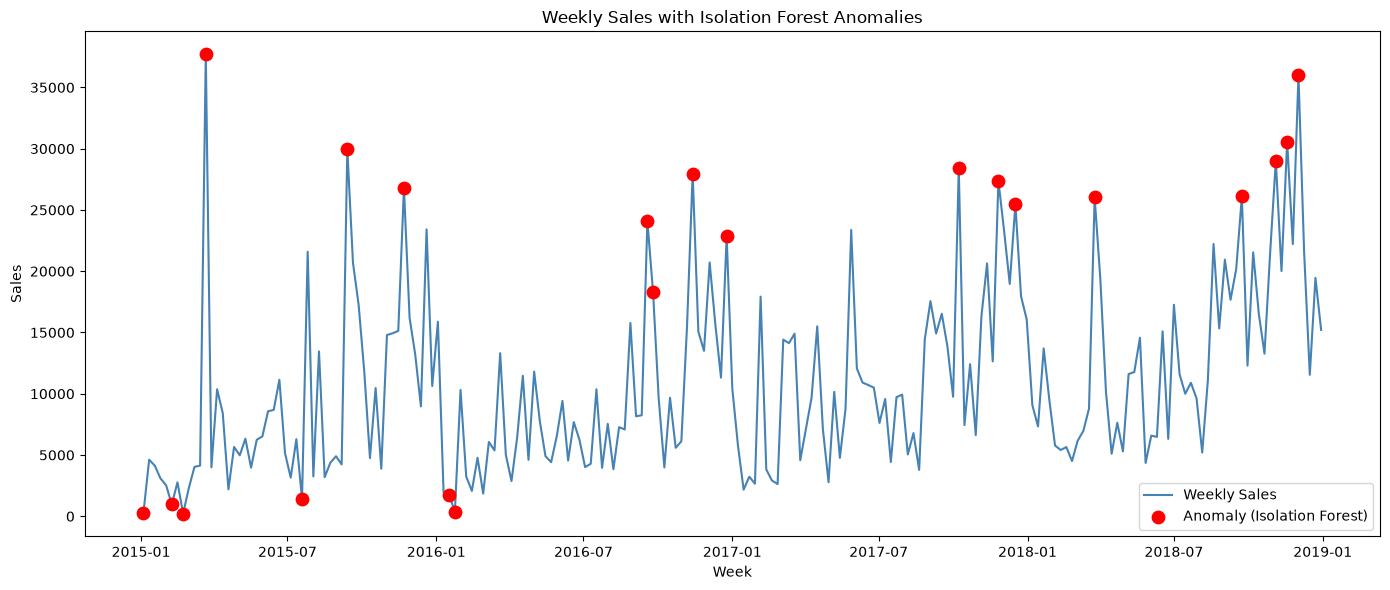

In [42]:
plt.figure(figsize=(14,6))
plt.plot(weekly_sales_df['Week'], weekly_sales_df['Sales'], label='Weekly Sales', color='steelblue')
plt.scatter(anomalies_if['Week'], anomalies_if['Sales'], color='red', s=80, label='Anomaly (Isolation Forest)', zorder=5)
plt.legend()
plt.title('Weekly Sales with Isolation Forest Anomalies')
plt.xlabel('Week')
plt.ylabel('Sales')
plt.tight_layout()
plt.savefig('charts/anomalies_isolation_forest.png')
plt.show()

In [43]:
window = 8  # 8-week rolling window
weekly_sales_df['RollingMean'] = weekly_sales_df['Sales'].rolling(window=window, min_periods=1).mean()
weekly_sales_df['RollingStd'] = weekly_sales_df['Sales'].rolling(window=window, min_periods=1).std()
weekly_sales_df['ZScore'] = (weekly_sales_df['Sales'] - weekly_sales_df['RollingMean']) / weekly_sales_df['RollingStd']

weekly_sales_df['Anomaly_Z'] = np.where(weekly_sales_df['ZScore'].abs() > 2, 'Anomaly', 'Normal')

anomalies_z = weekly_sales_df[weekly_sales_df['Anomaly_Z'] == 'Anomaly']
print(f"Z-Score method detected {len(anomalies_z)} anomalies:")
print(anomalies_z[['Week', 'Sales', 'ZScore']])

Z-Score method detected 6 anomalies:
          Week      Sales    ZScore
11  2015-03-22  37703.665  2.460650
29  2015-07-26  21590.080  2.136467
86  2016-08-28  15773.478  2.053924
89  2016-09-18  24095.960  2.122082
125 2017-05-28  23367.662  2.008225
168 2018-03-25  26029.904  2.435627


In [45]:
comparison_anomalies = pd.merge(
    weekly_sales_df[['Week', 'Sales']],
    weekly_sales_df[['Week', 'Anomaly_IF']],
    on='Week'
)
comparison_anomalies = comparison_anomalies.merge(weekly_sales_df[['Week', 'Anomaly_Z']], on='Week')

both_flagged = comparison_anomalies[(comparison_anomalies['Anomaly_IF']=='Anomaly') & (comparison_anomalies['Anomaly_Z']=='Anomaly')]
only_if = comparison_anomalies[(comparison_anomalies['Anomaly_IF']=='Anomaly') & (comparison_anomalies['Anomaly_Z']=='Normal')]
only_z = comparison_anomalies[(comparison_anomalies['Anomaly_IF']=='Normal') & (comparison_anomalies['Anomaly_Z']=='Anomaly')]

print(f"Flagged by BOTH methods: {len(both_flagged)}")
print(both_flagged[['Week','Sales']])
print(f"\nFlagged by Isolation Forest ONLY: {len(only_if)}")
print(f"Flagged by Z-Score ONLY: {len(only_z)}")

Flagged by BOTH methods: 3
          Week      Sales
11  2015-03-22  37703.665
89  2016-09-18  24095.960
168 2018-03-25  26029.904

Flagged by Isolation Forest ONLY: 18
Flagged by Z-Score ONLY: 3


In [46]:
vg_df = pd.read_csv('vgsales.csv')
print(vg_df.shape)
print(vg_df.columns.tolist())
vg_df.head()

(16598, 11)
['Rank', 'Name', 'Platform', 'Year', 'Genre', 'Publisher', 'NA_Sales', 'EU_Sales', 'JP_Sales', 'Other_Sales', 'Global_Sales']


,Rank,Name,Platform,Year,Genre,Publisher,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales
0,1,Wii Sports,Wii,2006.0,Sports,Nintendo,41.49,29.02,3.77,8.46,82.74
1,2,Super Mario Bros.,NES,1985.0,Platform,Nintendo,29.08,3.58,6.81,0.77,40.24
2,3,Mario Kart Wii,Wii,2008.0,Racing,Nintendo,15.85,12.88,3.79,3.31,35.82
3,4,Wii Sports Resort,Wii,2009.0,Sports,Nintendo,15.75,11.01,3.28,2.96,33.00
4,5,Pokemon Red/Pokemon Blue,GB,1996.0,Role-Playing,Nintendo,11.27,8.89,10.22,1.00,31.37


In [47]:
# Aggregate video game global sales by year
vg_yearly = vg_df.groupby('Year')['Global_Sales'].sum().reset_index()
vg_yearly.columns = ['Year', 'VG_Global_Sales_Millions']
vg_yearly = vg_yearly[(vg_yearly['Year'] >= 2015) & (vg_yearly['Year'] <= 2018)]  # overlap with our data
vg_yearly['Year'] = vg_yearly['Year'].astype(int)

# Aggregate our Superstore sales by year too
superstore_yearly = df.groupby('Order Year')['Sales'].sum().reset_index()
superstore_yearly.columns = ['Year', 'Superstore_Sales']

# Merge on Year - demonstrating multi-source join
merged_yearly = pd.merge(superstore_yearly, vg_yearly, on='Year', how='inner')
merged_yearly

,Year,Superstore_Sales,VG_Global_Sales_Millions
0,2015,479856.2081,264.44
1,2016,459436.0054,70.93
2,2017,600192.5500,0.05


In [48]:
# Aggregate video game global sales by year
vg_yearly = vg_df.groupby('Year')['Global_Sales'].sum().reset_index()
vg_yearly.columns = ['Year', 'VG_Global_Sales_Millions']
vg_yearly = vg_yearly[(vg_yearly['Year'] >= 2015) & (vg_yearly['Year'] <= 2018)]
vg_yearly['Year'] = vg_yearly['Year'].astype(int)

# Aggregate our Superstore sales by year
superstore_yearly = df.groupby('Order Year')['Sales'].sum().reset_index()
superstore_yearly.columns = ['Year', 'Superstore_Sales']

# Merge on Year
merged_yearly = pd.merge(superstore_yearly, vg_yearly, on='Year', how='inner')
merged_yearly

,Year,Superstore_Sales,VG_Global_Sales_Millions
0,2015,479856.2081,264.44
1,2016,459436.0054,70.93
2,2017,600192.5500,0.05


**Task 5: Multi-Source Merge Exercise (Superstore + Video Game Sales)**

As a practice exercise in combining multi-source data, we merged our Superstore yearly 
sales with the Video Game Sales dataset's yearly global sales figures, joined on Year.

| Year | Superstore Sales | VG Global Sales (Millions) |
|---|---|---|
| 2015 | 479,856.21 | 264.44 |
| 2016 | 459,436.01 | 70.93 |
| 2017 | 600,192.55 | 0.05 |

**Key limitation discovered**: The merge only returned 3 overlapping years (2015-2017), 
and even within that range, the video game dataset's figures collapse dramatically — 
from 264M in 2015 down to virtually 0.05M by 2017. This is a known characteristic of 
this dataset: it was compiled/scraped around 2016 and simply wasn't updated afterward, 
so 2017-2018 entries are almost entirely missing rather than reflecting real declining 
video game sales. Our Superstore data, by contrast, continued reliably through 2018.

**Business takeaway**: This exercise reflects a very real, common problem in industry — 
different data sources have different collection periods, update cadences, and reliability. 
A retail analytics team merging in third-party market data must always check for date 
coverage gaps before drawing conclusions; naively joining on Year here could mislead 
someone into thinking "the video game market crashed in 2017," when really the dataset 
just stopped being maintained. Also worth noting: comparing furniture/office/tech retail 
sales to global video game industry sales isn't a meaningful business comparison in the 
first place (different domains, different currencies/units — millions vs raw dollars). 
The value of this exercise was purely in demonstrating the *technical process* of 
aggregating and joining two structurally different sources on a common key, and in 
practicing the data-quality skepticism required before trusting a merged result.

In [49]:
# Total sales volume per sub-category
subcat_sales = df.groupby('Sub-Category')['Sales'].sum().reset_index()
subcat_sales.columns = ['Sub-Category', 'Total_Sales']

# Year-over-year growth rate (using first vs last year totals)
subcat_yearly = df.groupby(['Sub-Category', 'Order Year'])['Sales'].sum().reset_index()
subcat_pivot = subcat_yearly.pivot(index='Sub-Category', columns='Order Year', values='Sales')

first_year = subcat_pivot.columns.min()
last_year = subcat_pivot.columns.max()
subcat_pivot['Growth_Rate'] = ((subcat_pivot[last_year] - subcat_pivot[first_year]) / subcat_pivot[first_year]) * 100

# Sales volatility (std dev of monthly sales per sub-category)
subcat_monthly = df.groupby(['Sub-Category', pd.Grouper(key='Order Date', freq='ME')])['Sales'].sum().reset_index()
subcat_volatility = subcat_monthly.groupby('Sub-Category')['Sales'].std().reset_index()
subcat_volatility.columns = ['Sub-Category', 'Volatility']

# Average order value per sub-category
subcat_aov = df.groupby('Sub-Category')['Sales'].mean().reset_index()
subcat_aov.columns = ['Sub-Category', 'Avg_Order_Value']

# Combine all features
features_df = subcat_sales.merge(subcat_pivot[['Growth_Rate']], on='Sub-Category')
features_df = features_df.merge(subcat_volatility, on='Sub-Category')
features_df = features_df.merge(subcat_aov, on='Sub-Category')

features_df

,Sub-Category,Total_Sales,Growth_Rate,Volatility,Avg_Order_Value
0,Accessories,164186.7000,145.055961,2579.994809,217.178175
1,Appliances,104618.4030,165.242912,1821.621539,227.926804
2,Art,26705.4100,49.649531,330.488343,34.019631
3,Binders,200028.7850,65.778638,3848.223648,134.067550
4,Bookcases,113813.1987,49.846598,2220.405080,503.598224
5,Chairs,322822.7310,20.954677,4407.232960,531.833165
6,Copiers,146248.0940,479.729510,5500.774391,2215.880212
7,Envelopes,16128.0460,-12.121345,228.218688,65.032444
8,Fasteners,3001.9600,30.468364,48.742229,14.027850
9,Furnishings,89212.0180,106.824969,1360.017867,95.823865


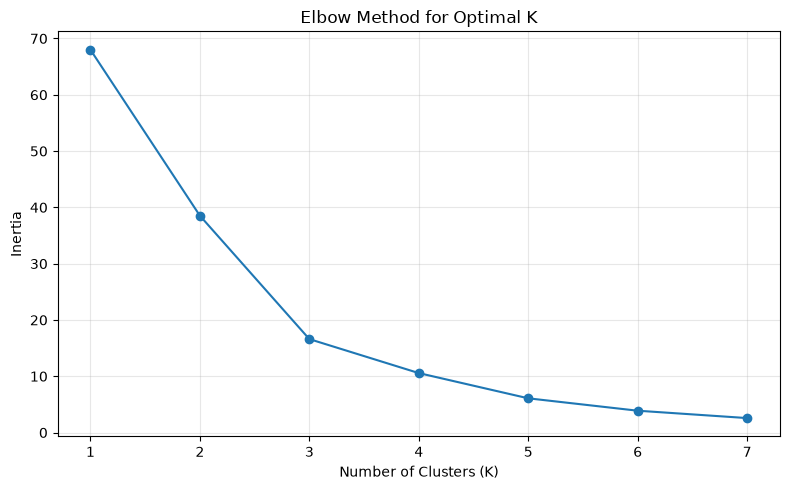

In [50]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

X_cluster = features_df[['Total_Sales', 'Growth_Rate', 'Volatility', 'Avg_Order_Value']]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_cluster)

inertias = []
K_range = range(1, 8)
for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    inertias.append(km.inertia_)

plt.figure(figsize=(8,5))
plt.plot(K_range, inertias, marker='o')
plt.title('Elbow Method for Optimal K')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('charts/elbow_method.png')
plt.show()

In [51]:
optimal_k = 3

kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
features_df['Cluster'] = kmeans.fit_predict(X_scaled)

features_df.sort_values('Cluster')

,Sub-Category,Total_Sales,Growth_Rate,Volatility,Avg_Order_Value,Cluster
6,Copiers,146248.0940,479.729510,5500.774391,2215.880212,0
0,Accessories,164186.7000,145.055961,2579.994809,217.178175,1
2,Art,26705.4100,49.649531,330.488343,34.019631,1
1,Appliances,104618.4030,165.242912,1821.621539,227.926804,1
7,Envelopes,16128.0460,-12.121345,228.218688,65.032444,1
4,Bookcases,113813.1987,49.846598,2220.405080,503.598224,1
9,Furnishings,89212.0180,106.824969,1360.017867,95.823865,1
8,Fasteners,3001.9600,30.468364,48.742229,14.027850,1
15,Supplies,46420.3080,11.276038,2025.094139,252.284283,1
12,Paper,76828.3040,91.901971,1024.824982,57.420257,1


In [52]:
cluster_summary = features_df.groupby('Cluster')[['Total_Sales', 'Growth_Rate', 'Volatility', 'Avg_Order_Value']].mean()
cluster_summary['Count'] = features_df['Cluster'].value_counts()
cluster_summary

,Total_Sales,Growth_Rate,Volatility,Avg_Order_Value,Count
Cluster,,,,,
0,146248.09400,479.729510,5500.774391,2215.880212,1
1,65326.20737,67.421837,1186.287889,150.189900,10
2,243671.10250,27.323655,3992.982732,599.193752,6


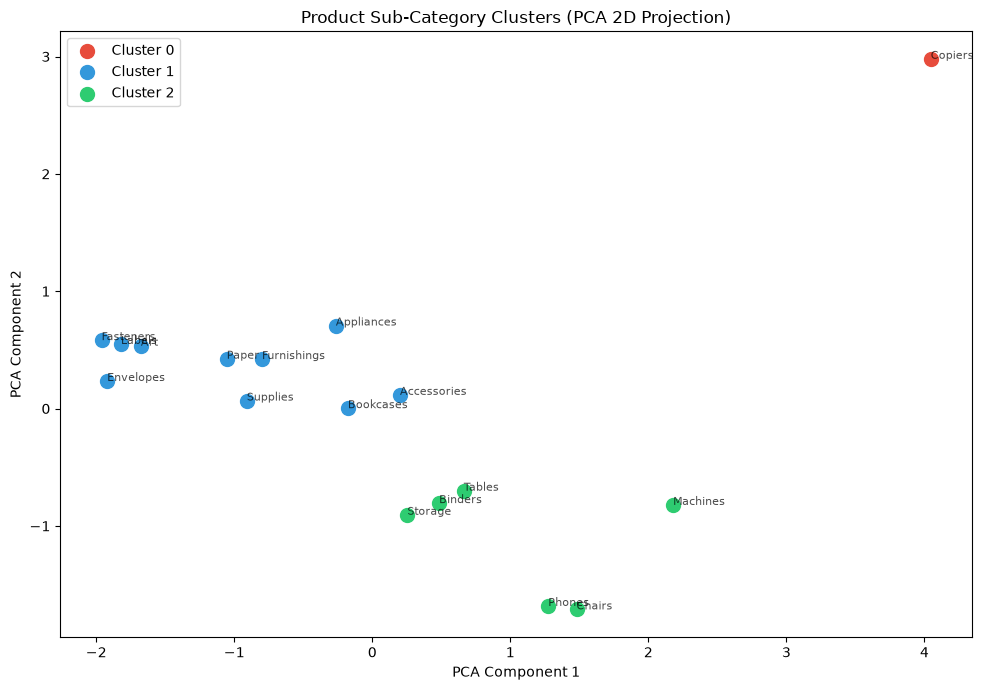

In [53]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

features_df['PCA1'] = X_pca[:,0]
features_df['PCA2'] = X_pca[:,1]

plt.figure(figsize=(10,7))
colors = ['#e74c3c', '#3498db', '#2ecc71', '#f39c12']
for cluster_id in sorted(features_df['Cluster'].unique()):
    cluster_data = features_df[features_df['Cluster'] == cluster_id]
    plt.scatter(cluster_data['PCA1'], cluster_data['PCA2'], 
                label=f'Cluster {cluster_id}', s=100, color=colors[cluster_id])
    for _, row in cluster_data.iterrows():
        plt.annotate(row['Sub-Category'], (row['PCA1'], row['PCA2']), fontsize=8, alpha=0.7)

plt.title('Product Sub-Category Clusters (PCA 2D Projection)')
plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
plt.legend()
plt.tight_layout()
plt.savefig('charts/product_clusters.png')
plt.show()

**Task 6: Product Demand Segmentation — Cluster Labels & Recommendations**

**Cluster 0 — "High Growth, High Volatility Outlier" (Copiers)**
- Total Sales: $146,248 | Growth: +479.7% | Volatility: 5,500.77 | AOV: $2,215.88
- A single sub-category standing entirely on its own: explosive growth, extremely high 
  order value, and the highest volatility in the dataset. Likely driven by a small number 
  of large, infrequent B2B/bulk orders rather than steady demand.
- **Stocking strategy**: Do NOT stock based on average monthly demand — this category 
  needs a made-to-order or just-in-time approach with strong supplier lead-time agreements, 
  since a single large order can spike demand unpredictably. Avoid holding large standing 
  inventory; instead maintain strong reorder flexibility.

**Cluster 1 — "Low Volume, Stable Demand" (10 sub-categories: Accessories, Art, Appliances, 
Envelopes, Bookcases, Furnishings, Fasteners, Supplies, Paper, Labels)**
- Avg Total Sales: $65,326 | Avg Growth: +67.4% | Avg Volatility: 1,186.29 | Avg AOV: $150.19
- The largest group — everyday, lower-cost items with the lowest volatility of the three 
  clusters. Reasonably steady, moderate growth.
- **Stocking strategy**: These are ideal for standard reorder-point inventory management — 
  predictable, low-risk items. Maintain moderate safety stock and use simple moving-average 
  reorder triggers; forecasting models (like our XGBoost from Task 3) will perform most 
  reliably here since low volatility means fewer surprise spikes.

**Cluster 2 — "High Volume, High Value Core Products" (6 sub-categories: Binders, Chairs, 
Machines, Phones, Storage, Tables)**
- Avg Total Sales: $243,671 | Avg Growth: +27.3% | Avg Volatility: 3,992.98 | Avg AOV: $599.19
- These are the business's revenue backbone — highest total sales, high order values, but 
  also meaningfully high volatility (large ticket items mean bigger swings). Growth is 
  positive but more modest than Cluster 1.
- **Stocking strategy**: These deserve the most forecasting attention and largest safety 
  stock buffers, since being out of stock on high-AOV items directly costs significant 
  revenue. Use the segment-level forecasting from Task 4 (Furniture/Technology models) 
  specifically for Chairs, Tables, and Phones, and apply extra buffer stock ahead of the 
  Nov/Dec seasonal peak identified in Tasks 1-2, since high volatility here likely 
  reflects exactly that seasonal swing.

**Overall recommendation**: Prioritize inventory planning effort proportional to cluster 
risk — Cluster 0 (Copiers) needs a fundamentally different, order-driven approach; 
Cluster 2 needs the heaviest forecasting/buffer investment given its revenue weight; 
Cluster 1 can run on lighter-touch, standard inventory rules.